# CIFAR-100 Classification with ResNetV2

In [10]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sympy import factor
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


os.makedirs('generated_images', exist_ok=True)
os.makedirs('saved_models', exist_ok=True)

Using device: cuda


## Data Loading and Preprocessing

In [11]:
def get_cifar100_loaders(batch_size=128):
    """Returns CIFAR-100 train and test loaders with appropriate transforms"""
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                             std=[0.2675, 0.2565, 0.2761]),
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                             std=[0.2675, 0.2565, 0.2761]),
    ])

    train_set = torchvision.datasets.CIFAR100(
        root='./data', train=True, download=True, transform=train_transform)
    test_set = torchvision.datasets.CIFAR100(
        root='./data', train=False, download=True, transform=test_transform)

    train_loader = DataLoader(train_set, batch_size=batch_size,
                              shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size,
                             shuffle=False, num_workers=4, pin_memory=True)

    return train_loader, test_loader

## Model Architecture

In [12]:
class StdConv2d(nn.Conv2d):
    """Standardized Conv2d layer with weight normalization"""

    def forward(self, x):
        # Weight standardization
        w = self.weight
        v, m = torch.var_mean(w, dim=[1, 2, 3], keepdim=True, unbiased=False)
        w = (w - m) / torch.sqrt(v + 1e-10)
        return F.conv2d(x, w, self.bias, self.stride,
                        self.padding, self.dilation, self.groups)


def conv3x3(in_planes, out_planes, stride=1, groups=1, bias=False):
    """3x3 convolution with standardization"""
    return StdConv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, groups=groups, bias=bias)


def conv1x1(in_planes, out_planes, stride=1, bias=False):
    """1x1 convolution with standardization"""
    return StdConv2d(in_planes, out_planes, kernel_size=1, stride=stride,
                     padding=0, bias=bias)

In [13]:
class PreActBottleneck(nn.Module):
    """Pre-activation version of the Bottleneck block"""

    def __init__(self, cin, cout=None, cmid=None, stride=1):
        super().__init__()
        cout = cout or cin
        cmid = cmid or cout // 4

        self.gn1 = nn.GroupNorm(32, cin)
        self.conv1 = conv1x1(cin, cmid)
        self.gn2 = nn.GroupNorm(32, cmid)
        self.conv2 = conv3x3(cmid, cmid, stride)
        self.gn3 = nn.GroupNorm(32, cmid)
        self.conv3 = conv1x1(cmid, cout)
        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or cin != cout:
            self.downsample = conv1x1(cin, cout, stride)

    def forward(self, x):
        out = self.relu(self.gn1(x))
        residual = self.downsample(out) if hasattr(self, 'downsample') else x

        out = self.conv1(out)
        out = self.conv2(self.relu(self.gn2(out)))
        out = self.conv3(self.relu(self.gn3(out)))

        return out + residual

In [14]:
class ResNetV2(nn.Module):
    """ResNetV2 implementation for CIFAR-100"""
    BLOCK_UNITS = {'r50': [3, 4, 6, 3]}

    def __init__(self, block_units, width_factor=1, num_classes=100):
        super().__init__()
        wf = width_factor

        self.root = nn.Sequential(
            StdConv2d(3, 64 * wf, kernel_size=3, stride=1, padding=1, bias=False),
            nn.GroupNorm(32, 64 * wf),
            nn.ReLU(inplace=True)
        )

        self.body = nn.Sequential(
            self._make_block(64 * wf, 128 * wf, block_units[0], stride=1),
            #nn.Dropout2d(0.2),
            self._make_block(128 * wf, 256 * wf, block_units[1], stride=2),
            #nn.Dropout2d(0.2),
            self._make_block(256 * wf, 512 * wf, block_units[2], stride=2),
            self._make_block(512 * wf, 1024 * wf, block_units[3], stride=2)
        )

        self.head = nn.Sequential(
            nn.GroupNorm(32, 1024 * wf),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1024 * wf, num_classes)
        )

    def _make_block(self, cin, cout, units, stride):
        layers = [PreActBottleneck(cin, cout, stride=stride)]
        for _ in range(1, units):
            layers.append(PreActBottleneck(cout, cout))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.root(x)
        x = self.body(x)
        return self.head(x)

## Training and Evaluation

In [15]:
def evaluate(model, test_loader, criterion):
    """Evaluate model performance on test set"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return total_loss / len(test_loader), 100 * correct / total



In [16]:
def train_model():
    """Complete training procedure"""
    # Hyperparameters
    batch_size = 128
    epochs = 1000
    lr = lr=1e-3
    weight_decay = 1e-3
    patience = 15

    # Data
    train_loader, test_loader = get_cifar100_loaders(batch_size)

    # Model
    model = ResNetV2(ResNetV2.BLOCK_UNITS['r50'], width_factor=1).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler()

    # Tracking
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    early_stop_counter = 0

    # Training loop
    for epoch in range(epochs):
        model.train()
        epoch_loss, correct, total = 0.0, 0, 0

        for inputs, targets in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}'):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        # Validation
        val_loss, val_acc = evaluate(model, test_loader, criterion)
        train_acc = 100 * correct / total

        # Update tracking
        train_losses.append(epoch_loss / len(train_loader))
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        scheduler.step()
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            model_path = 'saved_models/best_model.pth'
            torch.save(model.state_dict(), model_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch + 1}")
                break

        # Logging
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print(f"Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
        print(f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        print("-" * 50)

    # Plotting
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(train_losses, label='Train')
    ax.plot(val_losses, label='Validation')
    ax.set_title('Loss Curve')
    ax.legend()

    plt.tight_layout()
    path = 'generated_images/loss_function.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    return model


## Visualization

In [17]:
def visualize_predictions(model, test_loader, num_images=25):
    """Visualize model predictions with ground truth"""
    # Load class names
    with open('data/cifar-100-python/meta', 'rb') as f:
        class_names = pickle.load(f)['fine_label_names']

    # Get predictions
    model.eval()
    images, labels = next(iter(test_loader))
    with torch.no_grad():
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)

    # Denormalize
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1)
    images = images * std + mean
    images = torch.clamp(images, 0, 1)

    # Plot
    plt.figure(figsize=(12, 12))
    for idx in range(min(num_images, len(images))):
        plt.subplot(5, 5, idx + 1)
        plt.imshow(images[idx].permute(1, 2, 0).cpu())
        true_name = class_names[labels[idx]]
        pred_name = class_names[preds[idx]]
        color = 'green' if labels[idx] == preds[idx] else 'red'
        plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    path = 'generated_images/label_predictions.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()

Files already downloaded and verified
Files already downloaded and verified


Epoch 1/1000: 100%|██████████| 391/391 [00:44<00:00,  8.87it/s]



Epoch 1/1000
Train Loss: 4.0312 | Val Loss: 3.6091
Train Acc: 10.11% | Val Acc: 18.53%
LR: 1.00e-03
--------------------------------------------------


Epoch 2/1000: 100%|██████████| 391/391 [00:45<00:00,  8.60it/s]



Epoch 2/1000
Train Loss: 3.2294 | Val Loss: 3.0987
Train Acc: 27.01% | Val Acc: 30.22%
LR: 1.00e-03
--------------------------------------------------


...


Epoch 85/1000
Train Loss: 0.8548 | Val Loss: 1.7939
Train Acc: 99.02% | Val Acc: 70.87%
LR: 9.82e-04
--------------------------------------------------


Epoch 86/1000: 100%|██████████| 391/391 [00:47<00:00,  8.24it/s]



Epoch 86/1000
Train Loss: 0.8479 | Val Loss: 1.7932
Train Acc: 99.24% | Val Acc: 71.76%
LR: 9.82e-04
--------------------------------------------------


Epoch 87/1000: 100%|██████████| 391/391 [00:46<00:00,  8.36it/s]



Early stopping at epoch 87


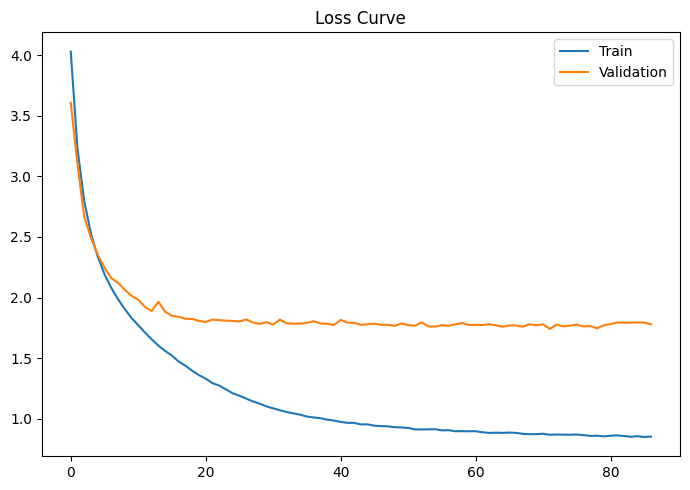

Best Validation Accuracy: 72.50%
Files already downloaded and verified
Files already downloaded and verified


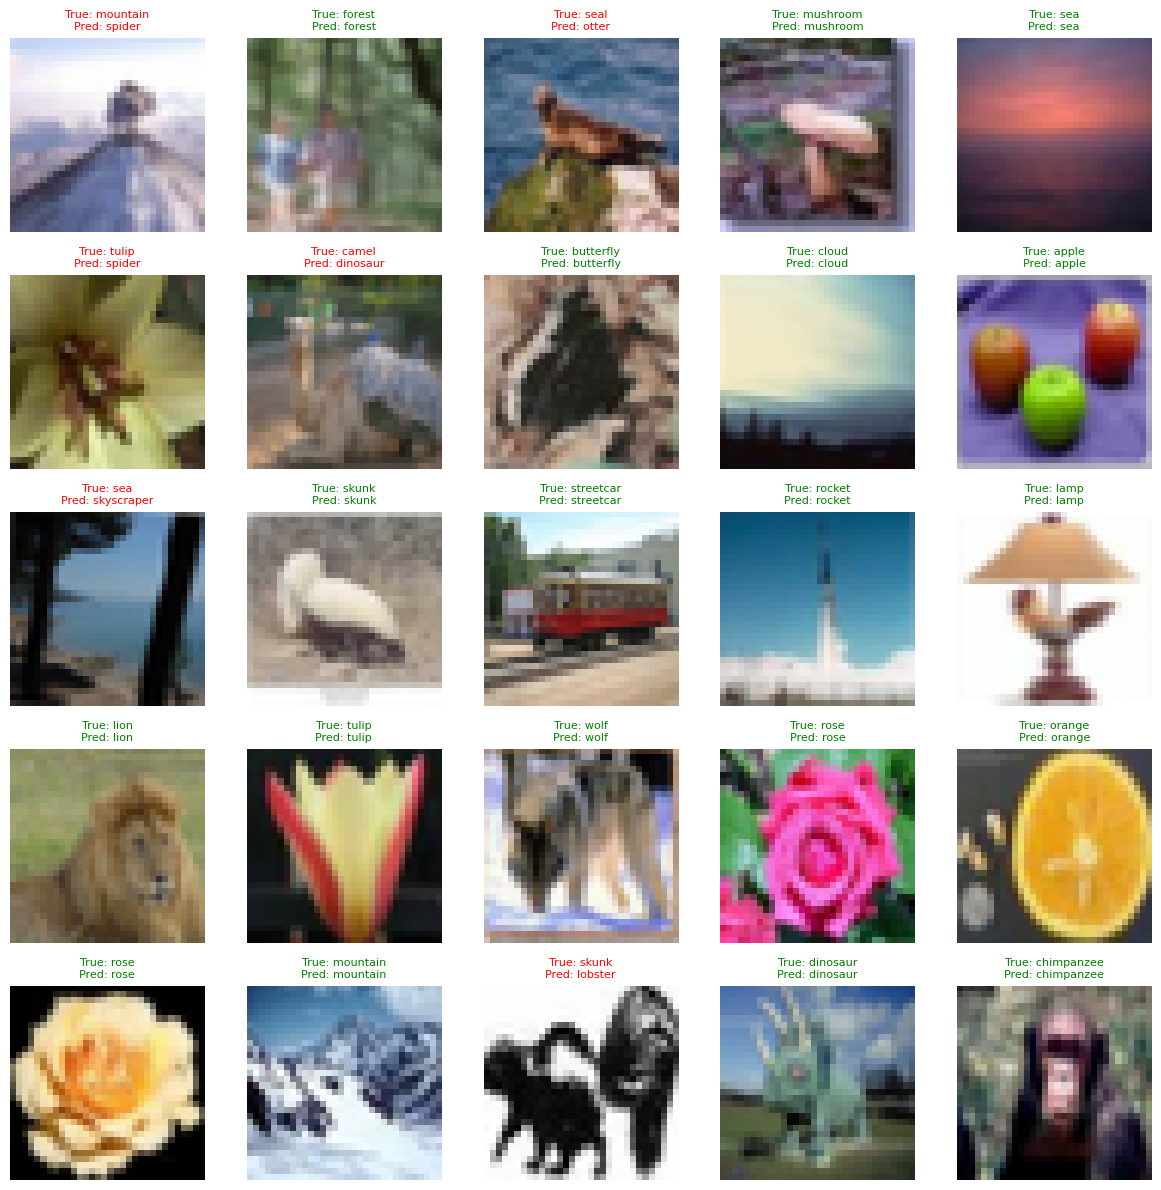

In [18]:
trained_model = train_model()

_, test_loader = get_cifar100_loaders(64)
visualize_predictions(trained_model, test_loader)